# Cross-Verification: psi_solve2 vs QMSolve

This notebook compares the results of your custom solver (`psi_solve2`) against the `QMSolve` package.

### Units Note
**Hartree Atomic Units** are a system of natural units where:
- $\hbar = 1$
- $m_e = 1$
- $e = 1$
- $4\pi\epsilon_0 = 1$

Your code sets `hbar = 1` and `m = 1`, which means it calculates energy in **Hartrees**.
`QMSolve` calculates energy in **eV** (Electron-Volts).

**Conversion:** $1 \text{ Hartree} \approx 27.211386 \text{ eV}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import functions as f
from qmsolve import Hamiltonian, SingleParticle 

# Conversion factor
Hartree_to_eV = 27.211386

## 1. Define the Test Case (Double Well)

In [2]:
# Parameters
L = 10.0
N = 512
depth = 2.0
separation = 1.0
center = 0.0
m_particle = 1.0

print(f"Simulating Double Well: L={L}, N={N}")

Simulating Double Well: L=10.0, N=512


## 2. Run psi_solve2 (Your Code)

In [3]:
# 1. Create Grid
x_full, dx, x_internal = f.make_grid(L=L, N=N)

# 2. Create Potential
V_internal = f.V_double_well(x_internal, depth=depth, separation=separation, center=center)

# Pad potential for the solver (walls at edges)
V_full = np.zeros_like(x_full)
V_full[1:-1] = V_internal
V_full[0] = 1e10
V_full[-1] = 1e10

# 3. Solve
T = f.kinetic_operator(N, dx, m=m_particle)
E_psi, psi_psi = f.solve(T, V_full, dx)

print("psi_solve2 Energies (Hartree):", E_psi[:5])

psi_solve2 Energies (Hartree): [1.40088643 2.0925331  4.45525173 6.91780793 9.87263201]


## 3. Run QMSolve (External Package)

In [4]:
# Define the same potential function for QMSolve
def double_well(particle):
    x = particle.x
    return depth * ( (x - center)**2 - separation )**2

# Setup Hamiltonian
H = Hamiltonian(particles = SingleParticle(m = m_particle), 
                potential = double_well, 
                spatial_ndim = 1, N = N, extent = L)

# Solve
eigenstates = H.solve(max_states = 10)
E_qm_eV = eigenstates.energies

# Convert to Hartree for comparison
E_qm_Hartree = E_qm_eV / Hartree_to_eV

print("QMSolve Energies (eV):", E_qm_eV[:5])
print("QMSolve Energies (Hartree):", E_qm_Hartree[:5])

Computing...
Took 0.011998414993286133
QMSolve Energies (eV): [ 38.16321636  57.08314973 121.53606095 188.76014178 269.3989016 ]
QMSolve Energies (Hartree): [1.40247235 2.09776708 4.4663679  6.93680733 9.90022712]


## 4. Compare Results

In [5]:
print(f"{'n':<3} | {'psi_solve2':<12} | {'QMSolve':<12} | {'% Diff':<8}")
print("-"*45)

for i in range(5):
    e1 = E_psi[i]
    e2 = E_qm_Hartree[i]
    diff_pct = abs(e1 - e2) / e2 * 100
    print(f"{i:<3} | {e1:<12.6f} | {e2:<12.6f} | {diff_pct:<7.4f}%")

n   | psi_solve2   | QMSolve      | % Diff  
---------------------------------------------
0   | 1.400886     | 1.402472     | 0.1131 %
1   | 2.092533     | 2.097767     | 0.2495 %
2   | 4.455252     | 4.466368     | 0.2489 %
3   | 6.917808     | 6.936807     | 0.2739 %
4   | 9.872632     | 9.900227     | 0.2787 %


## 5. Visual Comparison

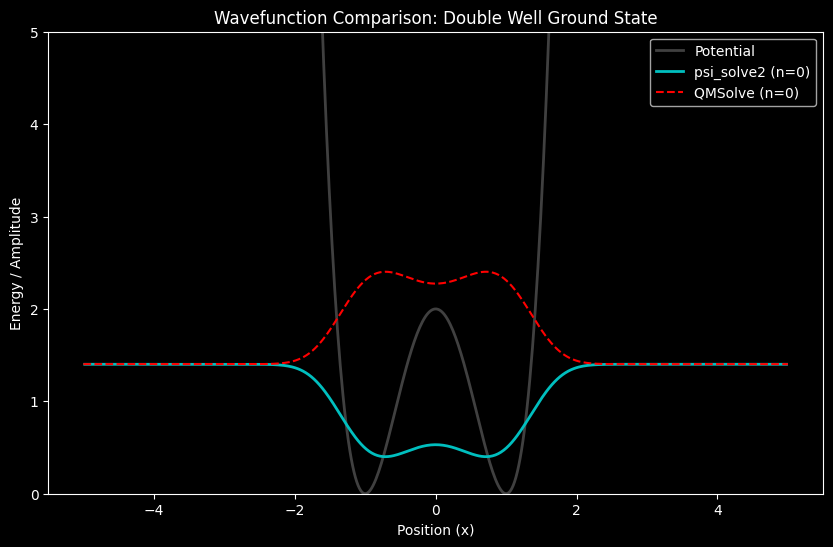

In [6]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plot Potential
plt.plot(x_full, V_full, color='gray', alpha=0.5, label='Potential', linewidth=2)

# Plot psi_solve2 wavefunction (State n=0)
scale = 1.0
psi_0_psi = psi_psi[:, 0] / np.max(np.abs(psi_psi[:, 0])) # Normalize max to 1 for plotting
plt.plot(x_internal, psi_0_psi * scale + E_psi[0], 'c-', label='psi_solve2 (n=0)', linewidth=2)

# Plot QMSolve wavefunction (State n=0)
# QMSolve stores wavefunctions in eigenstates.array
psi_0_qm = eigenstates.array[0]
psi_0_qm = psi_0_qm / np.max(np.abs(psi_0_qm)) # Normalize max to 1
# QMSolve grid
x_qm = np.linspace(-L/2, L/2, N)
plt.plot(x_qm, psi_0_qm * scale + E_qm_Hartree[0], 'r--', label='QMSolve (n=0)')

plt.ylim(0, 5)
plt.xlabel('Position (x)')
plt.ylabel('Energy / Amplitude')
plt.title('Wavefunction Comparison: Double Well Ground State')
plt.legend()
plt.show()